# 02 · Modelado de propensión a compra

**Qué hace este notebook (corre LOCAL, sobre el snapshot de la Gold):**
baseline → GBM → calibración → umbral → evaluación. El clustering y el cruce
clasificador × clustering van en un notebook aparte. MLflow + scoring batch se
hacen al final **en Databricks** (no aquí).

**Decisiones:**
- **Métrica:** PR-AUC + calibración (Brier). *Nunca* accuracy (evento raro ~6%).
- **Cuarentena anti-fuga:** se excluye 14–17 nov (`label_window_corrupt==1`), train *y* test.
- **Split temporal — Opción C:** train = Oct + Nov ≤ 23 · test = Nov 24–30 (*out-of-time*, mismo régimen).
- **Estratificación:** SOLO en la CV interna (`StratifiedKFold`), nunca en la frontera temporal (eso sería fuga).
- **`is_black_friday`:** solo para estratificar la evaluación, **no** es feature.
- **`sin_navegacion_previa`:** por defecto se MANTIENE como feature (Opción A); abajo puedes cambiarlo.
- **Desbalance:** `class_weight`/`scale_pos_weight` **dentro** del fit, nunca tocando el test.

## 0. Entorno

Si te falta alguna librería, descomenta y corre la celda de instalación una vez.

In [ ]:
# %pip install pandas pyarrow numpy scikit-learn imbalanced-learn lightgbm optuna matplotlib
# (shap es opcional, solo si quieres esa capa extra de diagnóstico:)
# %pip install shap

   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   -------------- ------------------------- 9.7/27.3 MB 47.4 MB/s eta 0:00:01
   ------------------------------------ --- 24.6/27.3 MB 59.5 MB/s eta 0:00:01
   ---------------------------------------- 27.3/27.3 MB 54.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)

   ------------- -------------------------- 1/3 [cloudpickle]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

# ── Ruta robusta: sube hasta encontrar .git, funciona desde workspace root
#    o desde notebooks/modeling/ ────────────────────────────────────────────
def _repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / ".git").exists():
            return p
    return start

REPO_ROOT = _repo_root(Path.cwd())
DATA_DIR  = REPO_ROOT / "data" / "gold_snapshot"
print(f"Repo : {REPO_ROOT}")
print(f"Data : {DATA_DIR} | existe: {DATA_DIR.exists()}")

# ── Parámetros del split (Opción C) ───────────────────────────────────────
CORTE_TRAIN = "2019-11-23"
TEST_INI    = "2019-11-24"
TEST_FIN    = "2019-11-30"

# ── Modo de iteración ──────────────────────────────────────────────────────
FRAC_ITERACION  = 0.10   # fracción del train para baseline/Optuna
N_TRIALS_OPTUNA = 20     # súbelo (≥50) para el fit final
MANTENER_SIN_NAV = True  # True = sin_navegacion_previa como feature (Opción A)

Repo : c:\Users\ylondono\dev\proyecto-integrador-g8
Data : c:\Users\ylondono\dev\proyecto-integrador-g8\data\gold_snapshot | existe: True


## 1. Carga del snapshot Gold

La Gold cargó **completa: 22.99M sesiones × 22 columnas** — grano correcto (filas = sesiones únicas), tasa de compra 0.061 y ~4.7 GB en memoria. El *downcast* de tipos lleva el tamaño hasta ahí sin pérdida de precisión en las features numéricas.

In [4]:
gold = pd.read_parquet(DATA_DIR)
print("Forma cruda:", gold.shape)

# Downcast para ahorrar memoria (numéricos) y normalizar booleanos/fecha
gold["target_purchase"] = gold["target_purchase"].astype("int8")
for c in ["is_weekend", "is_black_friday", "label_window_corrupt"]:
    gold[c] = gold[c].astype("int8")
gold["sin_navegacion_previa"] = gold["sin_navegacion_previa"].astype("int8")
gold["session_date"] = pd.to_datetime(gold["session_date"])
for c in gold.select_dtypes("float64").columns:
    gold[c] = pd.to_numeric(gold[c], downcast="float")
for c in gold.select_dtypes("int64").columns:
    gold[c] = pd.to_numeric(gold[c], downcast="integer")

print("\nColumnas:", list(gold.columns))
print("\nMemoria: %.2f GB" % (gold.memory_usage(deep=True).sum()/1e9))

# Sanity check: grano y tasa de etiqueta (esperado ~22.99M filas, tasa ~0.061)
print("\nFilas:", f"{len(gold):,}",
      "| sesiones únicas:", f"{gold['user_session'].nunique():,}")
print("Tasa target_purchase (FULL):", round(gold["target_purchase"].mean(), 4))

Forma cruda: (22995676, 22)

Columnas: ['user_session', 'target_purchase', 'user_id', 'total_views', 'distinct_products_viewed', 'brands_compared', 'categories_explored', 'categories_explored_cid', 'browsing_duration_sec', 'avg_price_viewed', 'max_price_viewed', 'electronics_view_share', 'sin_navegacion_previa', 'session_date', 'session_hour', 'day_of_week', 'is_weekend', 'is_black_friday', 'label_window_corrupt', 'revisit_intensity', 'views_per_minute', 'avg_inter_event_sec']

Memoria: 2.81 GB

Filas: 22,995,676 | sesiones únicas: 22,995,676
Tasa target_purchase (FULL): 0.061


## 2. Cuarentena anti-fuga (14–17 nov)

Se excluyen **3.28M sesiones (~14%)** de la ventana 14–17 nov: la etiqueta `purchase` está corrupta en ese periodo (15-nov: ~467k carritos, 0 compras; backlog volcado el 16–17). No es una decisión del split — es integridad de etiqueta, aplicada a train *y* test por igual.

> La tasa de compra queda en **0.0597** — la "tasa honesta" que reemplaza al 0.061 de la carga completa. Todo lo que sigue (split, modelo, evaluación) trabaja sobre esta base limpia.

In [5]:
n0 = len(gold)
gold = gold[gold["label_window_corrupt"] == 0].copy()
print(f"Excluidas por cuarentena 14–17 nov: {n0 - len(gold):,}")
print(f"Filas tras cuarentena: {len(gold):,} | tasa: {gold['target_purchase'].mean():.4f}")

Excluidas por cuarentena 14–17 nov: 3,283,933
Filas tras cuarentena: 19,711,743 | tasa: 0.0597


# 3. Split Temporal: Opción C

**Estructura del Dataset:**
* **Train:** 16.97M sesiones (1-oct al 23-nov) | Tasa de conversión: **6.03%**
* **Test:** 2.74M sesiones (24-nov al 30-nov) | Tasa de conversión: **5.60%**

La diferencia en la tasa de conversión entre ambos conjuntos es de apenas **7.1%**, lo que demuestra que train y test comparten el mismo régimen operativo. Esto garantiza una correcta **calibración de las probabilidades**. Debido a que el **30.6% del test** se concentra en el Black Friday (29–30 de noviembre), los resultados se reportarán desagregados (con y sin BF).


### Justificación Técnica y de Negocio (Por qué Opción C)

1. **Mitigación del Concept Drift:** La conversión por sesión decae de octubre (~6.8%) a inicios de noviembre (~5.0%). Un split que entrene solo en octubre (Opción A) dejaría al modelo descalibrado. Al incluir noviembre en Train, el modelo captura la deriva de la conversión y aprende el régimen real bajo el cual será evaluado.
2. **Estabilidad de Features:** La distribución de precios es consistente entre ventanas ($\text{PSI} \approx 0$), confirmando que el *drift* es del comportamiento del *target* y no de la escala de las variables clave.
3. **Réplica del Escenario de Producción:** Se rechaza el split aleatorio tradicional. El split temporal respeta la consistencia cronológica del negocio (entrenar con el pasado para predecir el futuro) sin pretender separar usuarios: un mismo cliente que navega antes y después del corte aparece en train y en test, lo cual es **realista** (en producción el modelo también ve clientes recurrentes). La ausencia de **fuga (data leakage)** la garantizan las *features intra-sesión y previas al corte* (ninguna variable usa información posterior al primer evento cart/purchase de la sesión), no una disjunción de usuarios.


### Invariantes del Diseño Experimental

* **Exclusión de la Ventana Corrupta (14–17 de noviembre):** Se eliminan por completo las sesiones donde `label_window_corrupt == 1` (ej. 467k carritos con 0 compras el 15-nov). **No se utiliza una variable bandera (*flag*)** para absorber este comportamiento, ya que el fallo radica en la corrupción del *target* (falsos negativos). Mantener estas filas sesgaría el aprendizaje en Train y penalizaría artificialmente la evaluación en Test al contrastar predicciones correctas contra etiquetas falsas. Además, este *flag* no existirá en producción.
* **Estrategia de Validación:** Se aplica `StratifiedKFold` **únicamente en la validación cruzada interna del Train** para asegurar la representatividad de la clase minoritaria (~6%). Jamás se estratifica la frontera temporal para evitar el anacronismo de los datos.
* **Evaluación de Atípicos (Black Friday):** El comportamiento extremo de BF es real y válido, por lo que se mantiene en el Test. La variable `is_black_friday` se usará exclusivamente como segmentador en la evaluación pos-modelado para reportar métricas con y sin este evento, nunca como *feature*.
* **Métricas de Rendimiento:** Se opta estrictamente por **PR-AUC** (debido al desbalance de clases) y **Brier Score** (para medir la calidad de la calibración de probabilidad). Se descarta el uso de *Accuracy*.


### Caveat Abierto (Riesgo Técnico)
Se identificó un incremento abrupto en el volumen de eventos `cart` durante noviembre. Se encuentra bajo validación si esto responde a un cambio genuino en el comportamiento del usuario o a una modificación en el protocolo de medición del *pipeline* de datos. Si se confirma lo segundo, se documentará como una limitación en la defensa, aunque no altera la estructura del split propuesto.

In [7]:
# Verificar que la cuarentena ya fue aplicada sobre gold antes de llegar aquí
assert (gold["label_window_corrupt"] == 0).all(), \
    "ERROR: quedan filas con label_window_corrupt==1. Correr la celda de cuarentena antes del split."

corte = pd.Timestamp(CORTE_TRAIN)
ini,  fin = pd.Timestamp(TEST_INI), pd.Timestamp(TEST_FIN)

mask_train = gold["session_date"] <= corte
mask_test  = (gold["session_date"] >= ini) & (gold["session_date"] <= fin)

train = gold[mask_train].copy()
test  = gold[mask_test].copy()

print(f"TRAIN: {len(train):,} filas | {train['session_date'].min().date()} → "
      f"{train['session_date'].max().date()} | tasa {train['target_purchase'].mean():.4f}")
print(f"TEST : {len(test):,} filas  | {test['session_date'].min().date()} → "
      f"{test['session_date'].max().date()} | tasa {test['target_purchase'].mean():.4f}")

brecha = abs(train["target_purchase"].mean() - test["target_purchase"].mean()) \
         / train["target_purchase"].mean() * 100
print(f"Brecha de tasa train↔test: {brecha:.1f}%  "
      f"({'SANO — mismo régimen' if brecha < 10 else '⚠ revisar corte'})")

# Máscara BF (29 y 30-nov) — solo para estratificar la evaluación, no como feature.
# is_black_friday en la Gold solo marca el 29; la fecha captura ambos días.
bf_window = test["session_date"].isin(
    [pd.Timestamp("2019-11-29"), pd.Timestamp("2019-11-30")]).values
print(f"\nFilas BF (29–30 nov) en test : {bf_window.sum():,}  ({bf_window.mean()*100:.1f}%)")

TRAIN: 16,967,843 filas | 2019-10-01 → 2019-11-23 | tasa 0.0603
TEST : 2,743,900 filas  | 2019-11-24 → 2019-11-30 | tasa 0.0560
Brecha de tasa train↔test: 7.1%  (SANO — mismo régimen)

Filas BF (29–30 nov) en test : 838,543  (30.6%)


## 4. X/Y y selección de features

Quedan **17 features**. Se excluyen los identificadores (`user_session`, `user_id`), el target, `session_date` (solo para el split), `is_black_friday` (solo para estratificar la evaluación) y label_window_corrupt (ya usada en la cuarentena). `session_hour` entra como `hour_sin`/`hour_cos`(codificación cíclica, para que las 23h y las 0h queden "cerca").  

¿Por qué se quitan `user_id` y `user_session` si parecería que la "continuidad" de una persona importa? Porque son **etiquetas de identidad, no comportamiento:** `user_session` es único en cada fila (no generaliza nada) y usar user_id sería "memorizar personas" (el modelo no sabría qué hacer con un usuario nuevo). Pero quitar el identificador no quita la información de interés repetido:

- Si alguien insiste en el mismo producto dentro de la visita, eso sí está capturado: `revisit_intensity` mide cuánto se re-miran los mismos productos (relación entre `total_views` y `distinct_products_viewed`), y `views_per_minute` la intensidad. Ese tipo de "estoy muy interesada en esto" ya entra al modelo.
- Lo que no se captura es la historia entre sesiones distintas (volver mañana a ver lo mismo). Es una decisión consciente de alcance: el EDA mostró que la compra se decide rapidísimo y dentro de la misma sesión (mediana 2.2 min, 77% en menos de 5), y la intervención de negocio es inmediata/en pantalla durante la visita. Modelar por sesión encaja con esa acción y evita riesgos de fuga temporal. La continuidad entre sesiones queda como extensión futura (features de historia de usuario) y se conecta con la palanca de recurrentes del A/B.

In [8]:
TARGET   = "target_purchase"
ID_COLS  = ["user_session", "user_id"]
EXCLUIR  = ID_COLS + [TARGET, "session_date", "is_black_friday", "label_window_corrupt"]

def add_cyclic_hour(df):
    df = df.copy()
    df["hour_sin"] = np.sin(2*np.pi*df["session_hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["session_hour"]/24)
    return df.drop(columns=["session_hour"])

train = add_cyclic_hour(train)
test  = add_cyclic_hour(test)

FEATURES = [c for c in train.columns if c not in EXCLUIR]
if not MANTENER_SIN_NAV:
    FEATURES = [c for c in FEATURES if c != "sin_navegacion_previa"]

print(f"{len(FEATURES)} features:\n", FEATURES)

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

17 features:
 ['total_views', 'distinct_products_viewed', 'brands_compared', 'categories_explored', 'categories_explored_cid', 'browsing_duration_sec', 'avg_price_viewed', 'max_price_viewed', 'electronics_view_share', 'sin_navegacion_previa', 'day_of_week', 'is_weekend', 'revisit_intensity', 'views_per_minute', 'avg_inter_event_sec', 'hour_sin', 'hour_cos']


## 5. Muestra estratificada para iterar

Para baseline y Optuna se usa el **10% del train** (1.70M filas), con la tasa de positivos preservada (0.0603). Esto reduce el tiempo de cada trial de Optuna en ~10× sin sacrificar representatividad. El **fit final** usa el train completo (16.97M).

In [9]:
from sklearn.model_selection import train_test_split
if FRAC_ITERACION < 1.0:
    X_it, _, y_it, _ = train_test_split(
        X_train, y_train, train_size=FRAC_ITERACION,
        stratify=y_train, random_state=RANDOM_STATE)
else:
    X_it, y_it = X_train, y_train
print(f"Muestra de iteración: {len(X_it):,} filas | tasa {y_it.mean():.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Muestra de iteración: 1,696,784 filas | tasa 0.0603


## 6. Baseline trivial — la trampa del accuracy

El modelo "nadie compra" logra **94.4% de accuracy pero PR-AUC 0.056** (= la tasa base): no detecta ni una compra. Es la demostración de por qué el accuracy miente con clases desbalanceadas. **Cualquier modelo serio debe superar PR-AUC = 0.056** para agregar valor real.

In [9]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_it, y_it)
acc_dummy = dummy.score(X_test, y_test)
base_rate = y_test.mean()
print(f"Accuracy del Dummy 'nadie compra': {acc_dummy:.4f}  ← parece buenísimo")
print(f"PR-AUC del Dummy (≈ tasa base):    {base_rate:.4f}  ← no detecta NINGUNA compra")
print("\nMoraleja: cualquier modelo serio debe superar PR-AUC =", round(base_rate, 4))

Accuracy del Dummy 'nadie compra': 0.9440  ← parece buenísimo
PR-AUC del Dummy (≈ tasa base):    0.0560  ← no detecta NINGUNA compra

Moraleja: cualquier modelo serio debe superar PR-AUC = 0.056


## 7. Baseline serio — Regresión logística

¿Qué es el **PR-AUC y por qué lo usamos en vez de accuracy**? Como solo ~6 de cada 100 sesiones terminan en compra, el accuracy engaña: un modelo que diga "nadie compra" acierta el 94% y no sirve de nada (lo vimos en §6). El **PR-AUC** se concentra en la clase que nos importa —los compradores— combinando dos cosas a lo largo de todos los umbrales posibles: la precisión (de los que marco como probables compradores, cuántos compran de verdad) y el recall (de todos los compradores reales, cuántos logro capturar).  

**La vara del azar** = **la tasa base**. Un modelo que reparta probabilidades al azar obtiene un PR-AUC ≈ la proporción real de compradores (~0.056): si marcas gente al azar, ~5.6% compra. Ese es el piso a superar.  

**Resultado:** La logística logra PR-AUC 0.0966 ± 0.0006, es decir ~1.7× la línea del azar (0.0966 ÷ 0.056 ≈ 1.7) → el modelo **ordena a los compradores ~70% mejor que adivinar a ciegas**, y la variación mínima entre folds (±0.0006) muestra que es un resultado estable, no suerte. (El GBM lo sube luego a ~2.1×: 0.1172 ÷ 0.056.)  

**¿Qué significa para el negocio?** En vez de lanzar incentivos a toda la base a ciegas, el modelo rankea a los usuarios por probabilidad de compra; dirigir el presupuesto a los mejor posicionados concentra el esfuerzo donde hay más chance de éxito que una campaña uniforme. (Cuánto mejora exactamente la "tasa de acierto" al intervenir depende del umbral que elijas: eso se lee en la curva precisión/recall de §11, y en la cabeza del ranking suele ser bastante mayor que el promedio.)

Pipeline: `StandardScaler` + `class_weight='balanced'` evaluado con `StratifiedKFold` de 5 folds y PR-AUC como métrica.

In [10]:
preproc = ColumnTransformer(
    [("num", StandardScaler(), FEATURES)], remainder="drop")

pipe_log = Pipeline([
    ("prep", preproc),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE))])

pr_auc_log = cross_val_score(pipe_log, X_it, y_it, cv=cv,
                             scoring="average_precision", n_jobs=-1)
print(f"PR-AUC logística (CV): {pr_auc_log.mean():.4f} ± {pr_auc_log.std():.4f}")
print("(se elige por promedio Y variabilidad, no por el fold más alto)")

PR-AUC logística (CV): 0.0966 ± 0.0006
(se elige por promedio Y variabilidad, no por el fold más alto)


### 7.bis Comparación de familias (RF + XGBoost + LightGBM)

Se comparan las tres familias de árboles (bagging + boosting) bajo la **misma CV, métrica (PR-AUC) y muestra**, con ajustes modestos y comparables (sin tunear), para elegir familia antes de afinar a fondo:

| modelo | PR-AUC (CV) | std | brecha train−CV (overfit) |
|---|---|---|---|
| XGBoost | 0.1185 | 0.0022 | 0.0271 |
| LightGBM | 0.1184 | 0.0018 | 0.0176 |
| RandomForest | 0.1157 | 0.0028 | 0.0222 |
| Logística (baseline) | 0.0957 | 0.0012 | — |
| Dummy (azar) | 0.0560 | — | — |

**Lectura:** las tres familias de árboles están **empatadas** — la diferencia entre XGBoost (0.1185) y LightGBM (0.1184) es **0.0001**, menor que la variabilidad entre folds (±0.0022), así que no es significativa. El rango de las tres familias es **0.116–0.119**. Todas superan claramente a la logística (0.096) y al azar (0.056), confirmando que la señal es **no lineal**. **LightGBM tiene la menor brecha de overfitting (0.0176)** → es el que mejor generaliza. Se elige **LightGBM** por ese mejor control de sobreajuste y porque, tras afinarlo con Optuna, alcanza **PR-AUC 0.1235** (por encima de cualquier familia sin tunear): lo que mueve la aguja es el **tuning**, no la familia.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import average_precision_score
import xgboost as xgb, lightgbm as lgb, pandas as pd

# Muestra de comparación (estratificada) — rápida y justa para todos
N_COMPARE = 400_000
X_cmp, _, y_cmp, _ = train_test_split(X_it, y_it, train_size=min(N_COMPARE, len(X_it)),
                                      stratify=y_it, random_state=RANDOM_STATE)
spw = (y_cmp == 0).sum() / (y_cmp == 1).sum()

# Modelos REGULARIZADOS (profundidad limitada, hojas mínimas, subsampling, reg_lambda)
modelos = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=50,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, min_child_weight=5,
        scale_pos_weight=spw, eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_STATE),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, num_leaves=31, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, min_child_samples=50,
        scale_pos_weight=spw, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)}

filas = []
for nombre, mdl in modelos.items():
    cvs = cross_val_score(mdl, X_cmp, y_cmp, cv=cv, scoring="average_precision", n_jobs=-1)
    mdl.fit(X_cmp, y_cmp)                                        # para medir el train
    pr_tr = average_precision_score(y_cmp, mdl.predict_proba(X_cmp)[:, 1])
    filas.append({"modelo": nombre, "PR_AUC_CV": cvs.mean(), "std": cvs.std(),
                  "PR_AUC_train": pr_tr, "brecha_overfit": pr_tr - cvs.mean()})

ref = [{"modelo":"Logística","PR_AUC_CV":0.0957,"std":0.0012,"PR_AUC_train":None,"brecha_overfit":None},
       {"modelo":"Dummy (azar)","PR_AUC_CV":0.056,"std":0.0,"PR_AUC_train":None,"brecha_overfit":None}]
res = pd.concat([pd.DataFrame(filas), pd.DataFrame(ref)], ignore_index=True)
print(res.sort_values("PR_AUC_CV", ascending=False).round(4).to_string(index=False))

      modelo  PR_AUC_CV    std  PR_AUC_train  brecha_overfit
     XGBoost     0.1185 0.0022        0.1455          0.0271
    LightGBM     0.1184 0.0018        0.1360          0.0176
RandomForest     0.1157 0.0028        0.1379          0.0222
   Logística     0.0957 0.0012           NaN             NaN
Dummy (azar)     0.0560 0.0000           NaN             NaN


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20372\1929200201.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  res = pd.concat([pd.DataFrame(filas), pd.DataFrame(ref)], ignore_index=True)


## 8. GBM (LightGBM) + Optuna

El GBM alcanza **PR-AUC 0.1235 en CV** — ~29% mejor que la logística (0.096). Eso justifica la complejidad: la señal está en no-linealidades e interacciones (como anticipaba el EDA §5), no en relaciones lineales. `scale_pos_weight ≈ 15.8` (ratio negativas/positivas del train) corrige el desbalance dentro del fit, calculado solo del train.

Optuna optimiza el PR-AUC promedio en CV estratificada con TPE sampler (`N_TRIALS_OPTUNA = 20` para iterar; sube a ≥ 50 para el fit de producción).

In [12]:
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

spw = (y_it == 0).sum() / (y_it == 1).sum()   # scale_pos_weight ~ neg/pos (~15)
print("scale_pos_weight:", round(spw, 2))

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 200, 800),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves       = trial.suggest_int("num_leaves", 15, 255),
        max_depth        = trial.suggest_int("max_depth", 3, 12),
        min_child_samples= trial.suggest_int("min_child_samples", 20, 200),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        scale_pos_weight = spw, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    scores = []
    for tr_idx, va_idx in cv.split(X_it, y_it):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_it.iloc[tr_idx], y_it.iloc[tr_idx])
        p = m.predict_proba(X_it.iloc[va_idx])[:, 1]
        scores.append(average_precision_score(y_it.iloc[va_idx], p))
    return float(np.mean(scores))

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)
print(f"\nMejor PR-AUC (CV): {study.best_value:.4f}")
print("Mejores params:", study.best_params)

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scale_pos_weight: 15.6


Best trial: 13. Best value: 0.123528: 100%|██████████| 20/20 [1:18:12<00:00, 234.63s/it]


Mejor PR-AUC (CV): 0.1235
Mejores params: {'n_estimators': 684, 'learning_rate': 0.019696412975698033, 'num_leaves': 211, 'max_depth': 9, 'min_child_samples': 197, 'subsample': 0.9246803266602427, 'colsample_bytree': 0.8085840730822341, 'reg_lambda': 0.835852168204342}


In [11]:
# R4 — Variabilidad entre folds del modelo elegido (media ± std), lo que pide Terán.
# NO re-corre Optuna: una sola CV (5 folds) con los best_params ya hallados (~4-5 min).
# Requiere en memoria X_it, y_it, cv (de §4/§5). Si reiniciaste el kernel, corre §1,§4,§5
# (carga + features + muestra, ~2 min) — NO hace falta §8 (Optuna).
import lightgbm as lgb  
from sklearn.model_selection import cross_val_score

BEST_R4 = dict(n_estimators=684, learning_rate=0.019696412975698033, num_leaves=211,
               max_depth=9, min_child_samples=197, subsample=0.9246803266602427,
               colsample_bytree=0.8085840730822341, reg_lambda=0.835852168204342)
spw_r4 = (y_it == 0).sum() / (y_it == 1).sum()
gbm_best = lgb.LGBMClassifier(**BEST_R4, scale_pos_weight=spw_r4,
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
folds = cross_val_score(gbm_best, X_it, y_it, cv=cv, scoring="average_precision", n_jobs=1)
print("PR-AUC por fold:", [f"{s:.4f}" for s in folds])
print(f"MODELO ELEGIDO (LightGBM+Optuna): media = {folds.mean():.4f}  ±  std = {folds.std():.4f}  (5 folds)")

# Opcional: si 'study' sigue en memoria, muestra que el ganador no es un máximo aislado
try:
    top5 = sorted([t.value for t in study.trials if t.value is not None], reverse=True)[:5]
    print("Top-5 trials (media CV):", [f"{v:.4f}" for v in top5],
          f"| rango {max(top5)-min(top5):.4f}")
except NameError:
    pass

PR-AUC por fold: ['0.1234', '0.1261', '0.1236', '0.1220', '0.1225']
MODELO ELEGIDO (LightGBM+Optuna): media = 0.1235  ±  std = 0.0014  (5 folds)


## 9. Fit final + Calibración

En el test *out-of-time*, **PR-AUC 0.1172** — casi igual al 0.1235 de la CV. Esa cercanía es la mejor evidencia de que no hay fuga ni sobreajuste: el modelo rinde en datos futuros casi como en validación cruzada. **Brier 0.0515** indica probabilidades bien calibradas (el baseline de la tasa base sería ~0.056; el modelo baja de ahí).

> En la curva de calibración, los puntos deben seguir la diagonal; si se pegan a ella, las probabilidades son honestas y sirven directamente para definir el umbral de intervención.

El GBM final se re-entrena sobre el **train completo** (16.97M) con los mejores hiperparámetros de Optuna y se calibra con `CalibratedClassifierCV(method="isotonic", cv=3)`.

PR-AUC (test): 0.1172
Brier (test):  0.0515


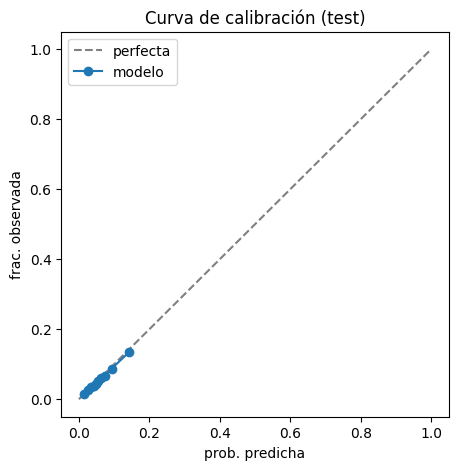

In [13]:
best = dict(study.best_params); best.update(scale_pos_weight=spw,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

gbm = lgb.LGBMClassifier(**best)
# Calibración con CV interna sobre el train completo
modelo = CalibratedClassifierCV(gbm, method="isotonic", cv=3)
modelo.fit(X_train, y_train)

p_test = modelo.predict_proba(X_test)[:, 1]
print("PR-AUC (test):", round(average_precision_score(y_test, p_test), 4))
print("Brier (test): ", round(brier_score_loss(y_test, p_test), 4))

# Curva de confiabilidad
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],"--",color="grey",label="perfecta")
plt.plot(mean_pred, frac_pos, "o-", label="modelo")
plt.xlabel("prob. predicha"); plt.ylabel("frac. observada")
plt.title("Curva de calibración (test)"); plt.legend(); plt.show()

## 10. Evaluación en test — con y sin Black Friday

El modelo rinde **algo mejor en BF** (PR-AUC 0.1287) que en días normales (0.1115); BF tiene tasa de compra más alta (0.0613) y calibración ligeramente peor (Brier 0.0559). El desempeño honesto de "régimen normal" es **~0.112**: BF infla ligeramente el global (0.1172). La diferencia no es grande → el modelo generaliza entre ambos regímenes.

| Subconjunto | PR-AUC | Brier | Tasa compra |
|---|---|---|---|
| Test completo | 0.1172 | 0.0515 | 0.0560 |
| Test ex-BF | 0.1115 | 0.0496 | — |
| Solo BF (29–30 nov) | 0.1287 | 0.0559 | 0.0613 |

Test completo      | n=2,743,900 | tasa=0.0560 | PR-AUC=0.1172 | Brier=0.0515
Test SIN BF        | n=1,905,357 | tasa=0.0536 | PR-AUC=0.1115 | Brier=0.0496
Test SOLO BF       | n=  838,543 | tasa=0.0613 | PR-AUC=0.1287 | Brier=0.0559


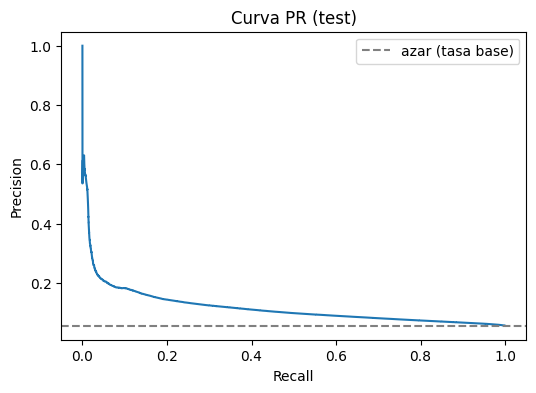

In [14]:
def reporta(nombre, yt, pt):
    print(f"{nombre:18s} | n={len(yt):>9,} | tasa={yt.mean():.4f} | "
          f"PR-AUC={average_precision_score(yt, pt):.4f} | Brier={brier_score_loss(yt, pt):.4f}")

reporta("Test completo", y_test, p_test)
reporta("Test SIN BF", y_test[~bf_window], p_test[~bf_window])
reporta("Test SOLO BF", y_test[bf_window],  p_test[bf_window])

# Curva PR del test completo
prec, rec, _ = precision_recall_curve(y_test, p_test)
plt.figure(figsize=(6,4))
plt.plot(rec, prec); plt.axhline(y_test.mean(), ls="--", color="grey", label="azar (tasa base)")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Curva PR (test)"); plt.legend(); plt.show()

## 11. Umbral operativo (no 0.5)

El modelo entrega una probabilidad continua; convertirla en decisión ("intervenir / no") requiere un **corte**, que es una **palanca de negocio**, no 0.5. Como solo ~6% compra, las probabilidades están comprimidas hacia abajo: el rango útil de operación es **0.05–0.15**, no 0.5 (con 0.5 no se marcaría casi a nadie).

**Punto de equilibrio (F1-óptimo): umbral ≈ 0.092.** Marca el **15% de las sesiones**, captura el **32% de los compradores** (recall) con **precisión 12.1%** — frente a la base de 5.6%, es un **lift de ~2.2×** (el grupo marcado compra más del doble que el promedio). En términos de negocio: con el 15% del esfuerzo se atrapa un tercio de las compras.

**El trade-off (tabla de alternativas):** subir el umbral cambia **alcance por precisión**. A 0.20 la precisión sube a 30% pero solo se marca el 0.4% (recall 2%); a 0.30, precisión 50% pero solo 1.2% de los compradores. Bajarlo amplía el alcance a costa de más falsos positivos.

**Cómo se elige según la intervención:**
- **Barata** (banner, email): umbral bajo (~0.09–0.10) → más alcance, capturas más compradores.
- **Costosa** (cupón, agente): umbral alto (≥0.20) → solo los más probables, proteges el presupuesto.

Para el **A/B test**, el umbral define a quién se le muestra el incentivo *dentro del segmento de electrónica* (C3/C4); el F1-óptimo es el default balanceado y el valor final se ajusta con Yeison según el costo y la capacidad de la campaña. El modelo no es un oráculo perfecto: da un **lift de ~2×**, suficiente para priorizar de forma rentable.

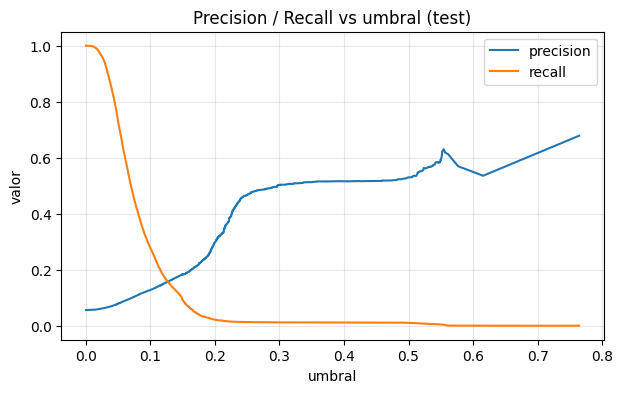

Elige el umbral según el costo del error, NO 0.5. Ej.: si intervenir es barato → umbral bajo (más recall).


In [15]:
prec, rec, thr = precision_recall_curve(y_test, p_test)
plt.figure(figsize=(7,4))
plt.plot(thr, prec[:-1], label="precision")
plt.plot(thr, rec[:-1],  label="recall")
plt.xlabel("umbral"); plt.ylabel("valor"); plt.title("Precision / Recall vs umbral (test)")
plt.legend(); plt.grid(alpha=.3); plt.show()
print("Elige el umbral según el costo del error, NO 0.5. "
      "Ej.: si intervenir es barato → umbral bajo (más recall).")

In [16]:
# Umbral operativo concreto: F1-óptimo como default balanceado + alternativas de negocio
prec, rec, thr = precision_recall_curve(y_test, p_test)
f1 = 2*prec[:-1]*rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
i = np.argmax(f1); umbral_f1 = thr[i]
print(f"Umbral F1-óptimo: {umbral_f1:.3f} → precision {prec[i]:.3f} · recall {rec[i]:.3f} · F1 {f1[i]:.3f}")
print(f"  marca el {(p_test>=umbral_f1).mean()*100:.1f}% de las sesiones\n")

print("Alternativas según política de campaña:")
for u in [0.10, 0.20, 0.30]:
    sel = p_test >= u
    precision_emp = y_test[sel].mean() if sel.sum() else 0
    recall_emp    = y_test[sel].sum() / y_test.sum()
    print(f"  umbral {u:.2f} → marca {sel.mean()*100:5.1f}% sesiones | precision {precision_emp:.3f} | recall {recall_emp:.3f}")

Umbral F1-óptimo: 0.092 → precision 0.121 · recall 0.324 · F1 0.176
  marca el 15.0% de las sesiones

Alternativas según política de campaña:
  umbral 0.10 → marca  12.1% sesiones | precision 0.128 | recall 0.277
  umbral 0.20 → marca   0.4% sesiones | precision 0.299 | recall 0.022
  umbral 0.30 → marca   0.1% sesiones | precision 0.503 | recall 0.012


## 12. Diagnóstico — importancia de features (built-in vs permutación)

Reportamos dos lecturas y mostramos por qué confiamos en una.

**Built-in de LightGBM** (`split` = nº de cortes, `gain` = ganancia): rápida pero sesgada. Favorece variables continuas (muchos puntos de corte) y se calcula sobre el train.
**Permutación**: revuelve cada feature en el **test** y mide la caída del PR-AUC. Mide impacto predictivo real, sin sesgo de cardinalidad.

**Por qué hicimos las dos — el contraste es el argumento:**
- `electronics_view_share` queda **casi al fondo en split count (0.042)** pero es la **#2 en permutación (0.203)** y alta en gain (0.195). Es de baja cardinalidad (pocos valores: 0/0.5/1), así que se usa en pocos cortes pero cada uno es muy informativo. **Si nos hubiéramos quedado con el split count, habríamos descartado erróneamente la feature de electrónica.**
- Las features continuas de ritmo (`views_per_minute`, `avg_inter_event_sec`, `revisit_intensity`) están **infladas en split count** y caen en permutación — el sesgo de cardinalidad en acción.
- `max_price_viewed` es #1 en las tres → señal robusta.

**Por eso la lectura válida es la permutación.**

### Resultado (permutación)
El poder predictivo se concentra en **precio + electrónica**: `max_price_viewed` (+0.038), `electronics_view_share` (+0.030), `avg_price_viewed` (+0.024). El engagement (`distinct_products_viewed`, `total_views`) aporta moderado; la hora (`hour_sin` +0.008) un poco; `sin_navegacion_previa` ≈ 0. Lo que predice la compra es **cuán caro/electrónico es lo que mira la persona, no cuánto navega** — coincide con el EDA y con el clustering (segmentos de electrónica = mayor conversión). Tres análisis independientes, un mismo insight.

In [17]:
# Permutación sobre una muestra del test (es costosa); usa el GBM ya calibrado
_sample_idx = X_test.sample(min(50000, len(X_test)), random_state=RANDOM_STATE).index
imp = permutation_importance(modelo, X_test.loc[_sample_idx], y_test.loc[_sample_idx],
                             scoring="average_precision", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
orden = np.argsort(imp.importances_mean)[::-1]
for i in orden:
    print(f"{FEATURES[i]:28s} {imp.importances_mean[i]:+.4f} ± {imp.importances_std[i]:.4f}")

max_price_viewed             +0.0383 ± 0.0015
electronics_view_share       +0.0300 ± 0.0021
avg_price_viewed             +0.0236 ± 0.0006
distinct_products_viewed     +0.0132 ± 0.0007
total_views                  +0.0126 ± 0.0006
hour_sin                     +0.0076 ± 0.0009
revisit_intensity            +0.0064 ± 0.0014
views_per_minute             +0.0054 ± 0.0008
avg_inter_event_sec          +0.0035 ± 0.0009
browsing_duration_sec        +0.0031 ± 0.0005
hour_cos                     +0.0018 ± 0.0011
categories_explored_cid      +0.0014 ± 0.0003
brands_compared              +0.0012 ± 0.0003
sin_navegacion_previa        +0.0000 ± 0.0000
is_weekend                   -0.0000 ± 0.0002
day_of_week                  -0.0001 ± 0.0005
categories_explored          -0.0001 ± 0.0004


In [18]:
import pandas as pd

# 1) Importancia BUILT-IN de LightGBM (split = nº de cortes, gain = ganancia total)
gbm_solo = lgb.LGBMClassifier(**study.best_params, scale_pos_weight=spw,
                              random_state=RANDOM_STATE).fit(X_train, y_train)
imp_split = pd.Series(gbm_solo.booster_.feature_importance(importance_type="split"), index=FEATURES)
imp_gain  = pd.Series(gbm_solo.booster_.feature_importance(importance_type="gain"),  index=FEATURES)
imp_perm  = pd.Series(imp.importances_mean, index=FEATURES)

# 2) Tabla comparativa normalizada (0-1) para comparar rankings de forma justa
comp = (pd.DataFrame({
            "built_in_split": imp_split / imp_split.sum(),
            "built_in_gain":  imp_gain  / imp_gain.sum(),
            "permutacion":    imp_perm  / imp_perm.sum()})
        .sort_values("permutacion", ascending=False).round(3))
print(comp)

                          built_in_split  built_in_gain  permutacion
max_price_viewed                   0.191          0.215        0.259
electronics_view_share             0.042          0.195        0.203
avg_price_viewed                   0.175          0.090        0.159
distinct_products_viewed           0.042          0.016        0.090
total_views                        0.043          0.045        0.085
hour_sin                           0.046          0.072        0.051
revisit_intensity                  0.065          0.095        0.043
views_per_minute                   0.072          0.037        0.037
avg_inter_event_sec                0.059          0.063        0.023
browsing_duration_sec              0.085          0.045        0.021
hour_cos                           0.048          0.026        0.012
categories_explored_cid            0.027          0.067        0.009
brands_compared                    0.036          0.020        0.008
sin_navegacion_previa             

Lo que se exporta para trabajar en databricks

In [19]:
import joblib
from pathlib import Path
ruta_modelo = Path("../../data/propension_model.joblib")
joblib.dump(modelo, ruta_modelo)
print(f"Modelo guardado: {ruta_modelo} ({ruta_modelo.stat().st_size/1e6:.1f} MB)")

Modelo guardado: ..\..\data\propension_model.joblib (47.1 MB)
